Step 1: Install SHAP and Load the Trained Random Forest Model

In [1]:
import shap

print(shap.__version__)

0.52.0


In [2]:
import pandas as pd
import numpy as np
import joblib
import shap
import matplotlib.pyplot as plt

In [3]:
rf_model = joblib.load("../models/random_forest.pkl")

In [5]:
print(type(rf_model))

<class 'sklearn.ensemble._forest.RandomForestClassifier'>


In [6]:
X_test = pd.read_csv("../data/processed/X_test_scaled.csv")

y_test = pd.read_csv("../data/processed/y_test.csv").squeeze()

In [66]:
print(X_test.shape)
print(y_test.shape)
print(X_test.head())

(56746, 30)
(56746,)
       Time        V1        V2        V3        V4        V5        V6  \
0 -0.707761  1.228821 -0.063408  0.274145  0.647465 -0.048135  0.372073   
1  1.273872 -0.203154  1.176678 -0.759595 -0.518472  0.629649 -0.721675   
2 -1.348111 -1.672836  1.401297  1.503940  2.175491  0.699791  1.062139   
3 -0.878056  0.819379 -1.124913  0.515025  0.513945 -1.009048  0.488484   
4  0.727104  2.009701  0.105635 -1.752759  0.588312  0.374801 -0.637884   

         V7        V8        V9  ...       V20       V21       V22       V23  \
0 -0.224231  0.079939  0.640759  ... -0.096566 -0.129554 -0.083779 -0.151661   
1  0.638893  0.243377 -0.157488  ... -0.098429  0.384629  1.206754 -0.082753   
2  1.114364 -0.535822 -0.252983  ...  0.828472 -0.525950 -0.408743 -0.280083   
3 -0.580672  0.187686 -0.999142  ... -0.110144 -0.057205 -0.168061 -0.198732   
4  0.009260 -0.129487  0.492619  ... -0.135479  0.008970  0.357394 -0.013472   

        V24       V25       V26       V27      

In [67]:
print(X_test.columns.tolist())

['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']


In [68]:
explainer = shap.TreeExplainer(rf_model)

In [69]:
print(type(explainer))

<class 'shap.explainers._tree.TreeExplainer'>


In [70]:
X_sample = X_test.iloc[:100]


In [71]:
print(X_sample.shape)

(100, 30)


In [72]:
shap_values = explainer(X_sample)

In [73]:
print(type(shap_values))

<class 'shap._explanation.Explanation'>


In [74]:
print(shap_values.values.shape)

(100, 30, 2)


In [75]:
fraud_shap = shap_values.values[:, :, 1]

In [76]:
print(fraud_shap.shape)

(100, 30)


In [77]:
fraud_shap = shap_values.values

In [78]:
if shap_values.values.ndim == 3:
    fraud_shap = shap_values.values[:, :, 1]
else:
    fraud_shap = shap_values.values

In [79]:
import numpy as np

np.save(
    "../reports/shap_values.npy",
    fraud_shap
)

In [80]:
X_sample.to_csv(
    "../reports/shap_sample.csv",
    index=False
)

Step 2: Global Model Explanation Using SHAP Summary Plot

In [81]:
import pandas as pd
import numpy as np
import shap
import joblib
import matplotlib.pyplot as plt

In [82]:
rf_model = joblib.load(
    "../models/random_forest.pkl"
)

In [83]:
X_test = pd.read_csv(
    "../data/processed/X_test_scaled.csv"
)

y_test = pd.read_csv(
    "../data/processed/y_test.csv"
).squeeze()

In [84]:
X_sample = X_test.iloc[:200]

In [85]:
print(X_sample.shape)

(200, 30)


In [86]:
explainer = shap.TreeExplainer(
    rf_model
)

In [87]:
shap_values = explainer(X_sample)

In [88]:
print(shap_values.values.shape)

(200, 30, 2)


In [89]:
if shap_values.values.ndim == 3:

    fraud_shap = shap_values.values[:, :, 1]

else:

    fraud_shap = shap_values.values

In [90]:
print(fraud_shap.shape)

(200, 30)


In [91]:
fraud_explanation = shap.Explanation(
    values=fraud_shap,
    base_values=shap_values.base_values[:, 1]
    if np.ndim(shap_values.base_values) > 1
    else shap_values.base_values,
    data=X_sample.values,
    feature_names=X_sample.columns.tolist()
)

<Figure size 1000x800 with 0 Axes>

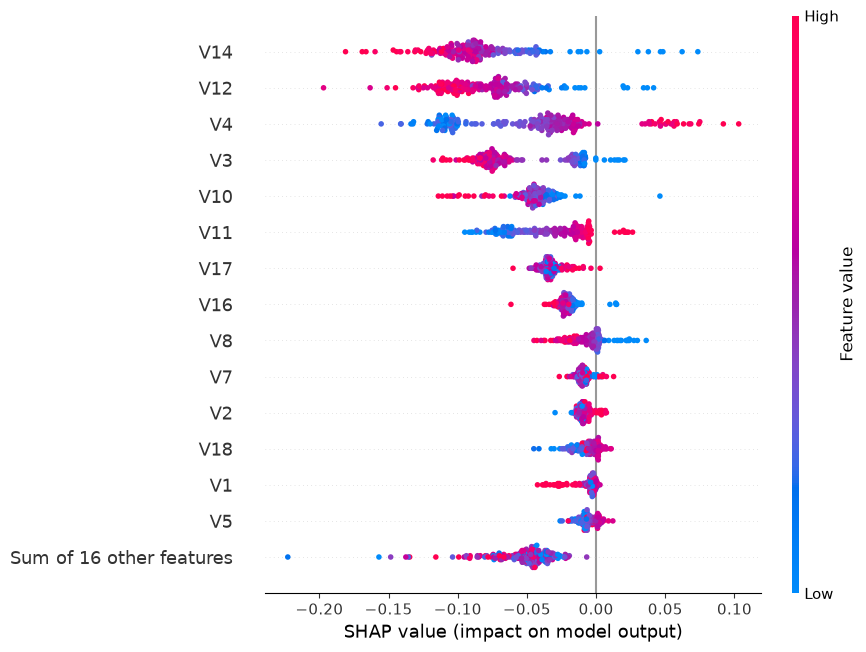

In [92]:
plt.figure(figsize=(10,8))

shap.plots.beeswarm(
    fraud_explanation,
    max_display=15,
    show=False
)

plt.savefig(
    "../images/shap_summary_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

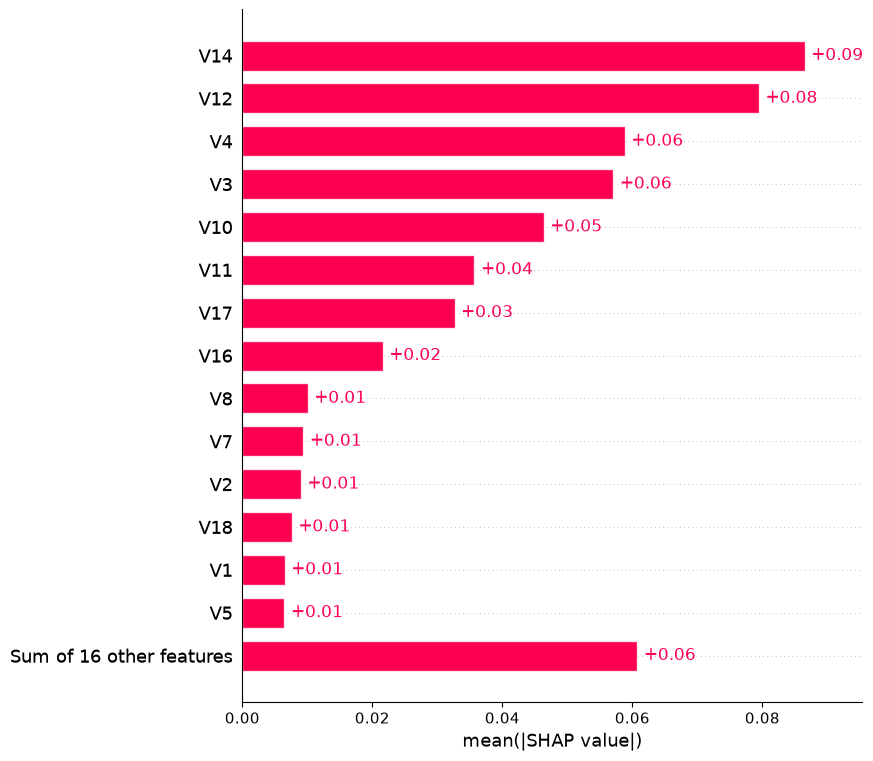

In [93]:
plt.figure(figsize=(10,8))

shap.plots.bar(
    fraud_explanation,
    max_display=15,
    show=False
)

plt.savefig(
    "../images/shap_bar_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [94]:
importance = pd.DataFrame({

    "Feature": X_sample.columns,

    "Importance": np.abs(
        fraud_shap
    ).mean(axis=0)

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(
    importance.head(15)
)

   Feature  Importance
14     V14    0.086508
12     V12    0.079465
4       V4    0.058824
3       V3    0.057062
10     V10    0.046347
11     V11    0.035713
17     V17    0.032640
16     V16    0.021588
8       V8    0.010043
7       V7    0.009374
2       V2    0.008985
18     V18    0.007609
1       V1    0.006500
5       V5    0.006474
9       V9    0.006442


In [95]:
importance.to_csv(
    "../reports/shap_feature_importance.csv",
    index=False
)

Step 3: Local Explanation Using SHAP Waterfall and Force Plots

In [96]:
import pandas as pd
import numpy as np
import shap
import joblib
import matplotlib.pyplot as plt

In [97]:
rf_model = joblib.load(
    "../models/random_forest.pkl"
)

In [98]:
X_test = pd.read_csv(
    "../data/processed/X_test_scaled.csv"
)

y_test = pd.read_csv(
    "../data/processed/y_test.csv"
).squeeze()

In [100]:
explainer = shap.TreeExplainer(
    rf_model
)

In [101]:
X_sample = X_test.iloc[:200]

In [103]:
shap_values = explainer(X_sample)

In [104]:
if shap_values.values.ndim == 3:

    fraud_values = shap_values.values[:, :, 1]

    base_values = shap_values.base_values[:, 1]

else:

    fraud_values = shap_values.values

    base_values = shap_values.base_values

In [129]:
fraud_explanation = shap.Explanation(

    values=fraud_values,

    base_values=base_values,

    data=X_sample.values,

    feature_names=X_sample.columns.tolist()

)

In [130]:
predictions = rf_model.predict(X_sample)

fraud_indices = np.where(predictions == 1)[0]

print(fraud_indices)

[]


In [131]:
fraud_index = fraud_indices[:0] 

print("Fraud Transaction Index:", fraud_index)

Fraud Transaction Index: []


In [123]:
fraud_index = fraud_indices[:10]

print("Fraud Transaction Index:", fraud_index)

Fraud Transaction Index: []


In [124]:
print(fraud_values.shape)

(200, 30)


<Figure size 1000x800 with 0 Axes>

<Figure size 1000x800 with 0 Axes>

<Figure size 1000x800 with 0 Axes>

<Figure size 1000x800 with 0 Axes>

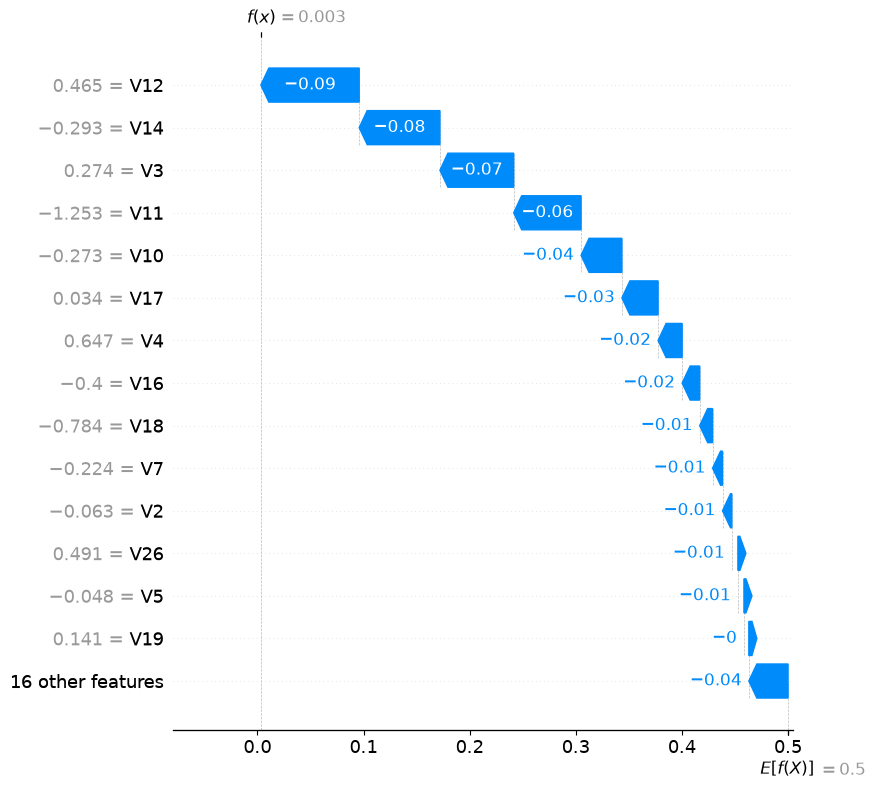

In [133]:
plt.figure(figsize=(10, 8))

shap.plots.waterfall(
    fraud_explanation[0],
    max_display=15,
    show=False
)

plt.savefig(
    "../images/fraud_waterfall_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

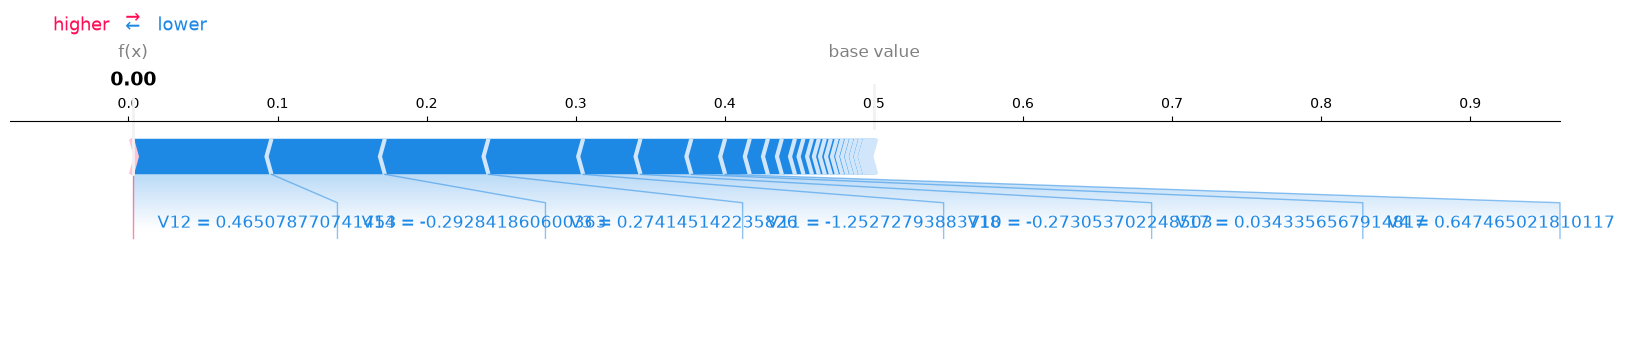

In [135]:
force_plot = shap.plots.force(
    fraud_explanation[0],
    matplotlib=True,
    show=False
)

plt.savefig(
    "../images/fraud_force_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [136]:
genuine_indices = np.where(predictions == 0)[0]

genuine_index = genuine_indices[0]

print(genuine_index)

0


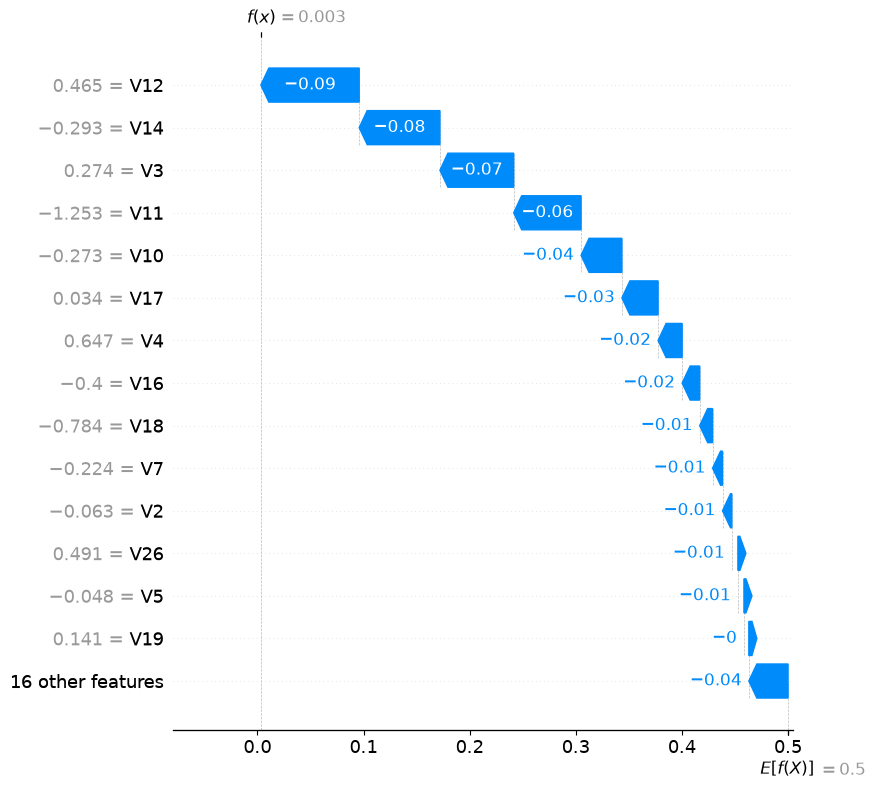

In [137]:
plt.figure(figsize=(10, 8))

shap.plots.waterfall(
    fraud_explanation[genuine_index],
    max_display=15,
    show=False
)

plt.savefig(
    "../images/genuine_waterfall_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

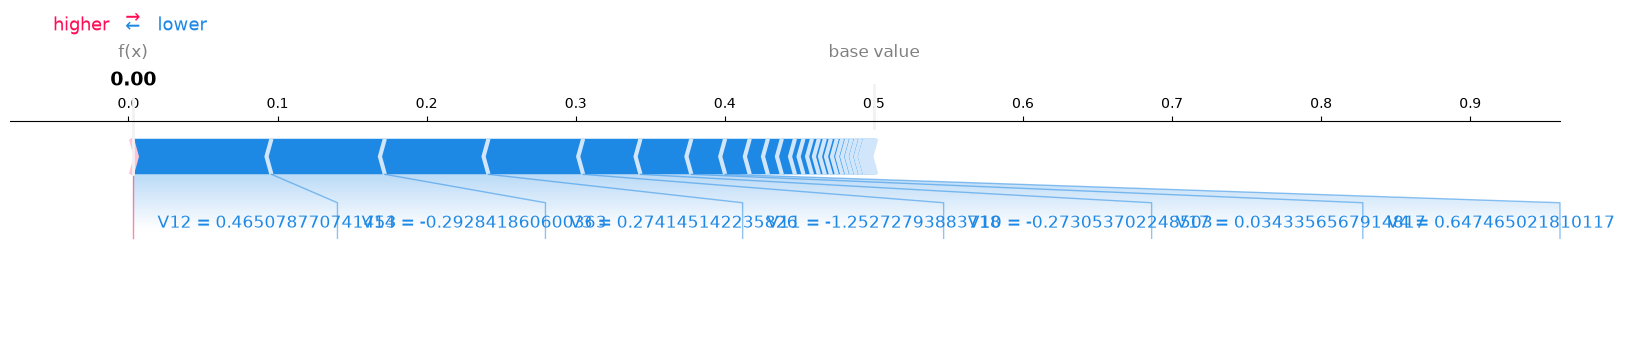

In [138]:
force_plot = shap.plots.force(
    fraud_explanation[genuine_index],
    matplotlib=True,
    show=False
)

plt.savefig(
    "../images/genuine_force_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [140]:
fraud_contribution = pd.DataFrame({

    "Feature": X_sample.columns,

    "SHAP Value": fraud_values[0]

})

fraud_contribution = fraud_contribution.sort_values(

    by="SHAP Value",

    ascending=False

)

fraud_contribution.to_csv(

    "../reports/fraud_transaction_explanation.csv",

    index=False

)

In [141]:
genuine_contribution = pd.DataFrame({

    "Feature": X_sample.columns,

    "SHAP Value": fraud_values[genuine_index]

})

genuine_contribution = genuine_contribution.sort_values(

    by="SHAP Value",

    ascending=False

)

genuine_contribution.to_csv(

    "../reports/genuine_transaction_explanation.csv",

    index=False

)